# Task
Demonstrate and compare K-Means and Hierarchical Clustering. Generate two distinct sample datasets, apply K-Means clustering to the first dataset including elbow method and visualization, and apply Hierarchical Clustering to the second dataset including linkage matrix, dendrogram, and visualization. Finally, provide a summary comparing the results and characteristics of both clustering methods.

## Generate Sample Datasets

### Subtask:
Generate two distinct sample datasets suitable for demonstrating K-Means and Hierarchical Clustering. Each dataset should have multiple features and distinguishable clusters.


**Reasoning**:
First, import the necessary library `make_blobs` from `sklearn.datasets`. Then, generate two distinct datasets with specified parameters for K-Means and Hierarchical Clustering respectively, and finally, print their shapes to verify the generation.



In [1]:
from sklearn.datasets import make_blobs

# Generate the first dataset for K-Means
X1, y1 = make_blobs(n_samples=300, n_features=2, centers=4, cluster_std=0.60, random_state=0)

# Generate the second dataset for Hierarchical Clustering
X2, y2 = make_blobs(n_samples=300, n_features=3, centers=3, cluster_std=[0.5, 1.0, 0.7], random_state=42)

# Print the shapes of the generated datasets
print(f"Shape of X1: {X1.shape}")
print(f"Shape of y1: {y1.shape}")
print(f"Shape of X2: {X2.shape}")
print(f"Shape of y2: {y2.shape}")

Shape of X1: (300, 2)
Shape of y1: (300,)
Shape of X2: (300, 3)
Shape of y2: (300,)


## Apply K-Means Clustering

### Subtask:
Apply K-Means clustering to the first sample dataset, determine an appropriate number of clusters using the elbow method, and then fit the K-Means model.


**Reasoning**:
The first part of the subtask involves applying the elbow method to determine the optimal number of clusters for K-Means. This requires importing `KMeans` and `matplotlib.pyplot`, iterating through a range of cluster numbers, fitting K-Means for each, storing the inertia, and then plotting the results to visualize the elbow curve.



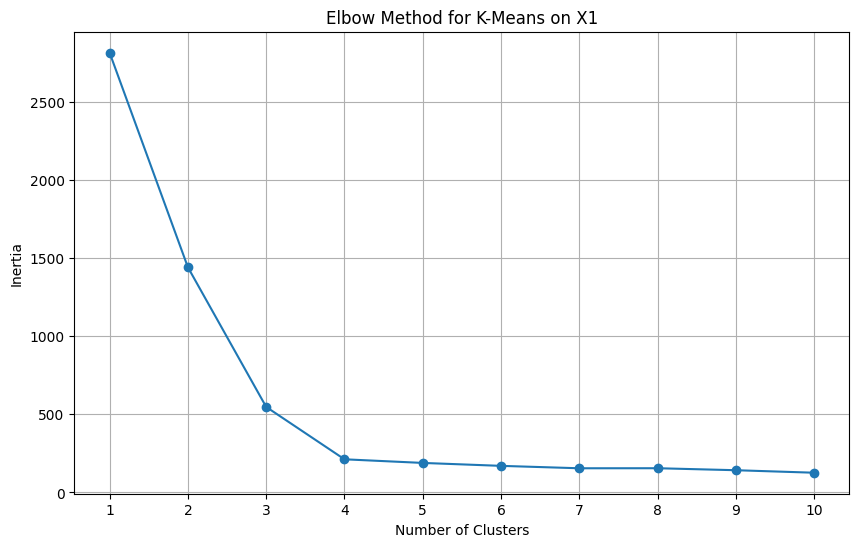

In [2]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Initialize an empty list to store SSE values
sse = []

# Loop through a range of possible number of clusters (e.g., from 1 to 10)
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init='auto')
    kmeans.fit(X1)
    sse.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), sse, marker='o')
plt.title('Elbow Method for K-Means on X1')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

**Reasoning**:
Based on the elbow plot from the previous step, the optimal number of clusters appears to be 4 (where the 'elbow' or bend in the curve is visible). The next logical step is to instantiate a K-Means model with this optimal number of clusters, fit it to the dataset `X1`, and then obtain the cluster labels for each data point.



In [3]:
k_optimal = 4 # Based on the elbow plot
kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init='auto')
kmeans.fit(X1)
kmeans_labels = kmeans.labels_

print(f"K-Means clustering applied with {k_optimal} clusters.")
print(f"First 10 cluster labels: {kmeans_labels[:10]}")

K-Means clustering applied with 4 clusters.
First 10 cluster labels: [0 2 1 2 0 0 3 1 2 2]


**Reasoning**:
To visually represent the K-Means clustering results, I will plot the data points from `X1` using `matplotlib.pyplot`, coloring them based on the `kmeans_labels` and also marking the cluster centroids identified by the `kmeans` model. This will demonstrate the formed clusters.



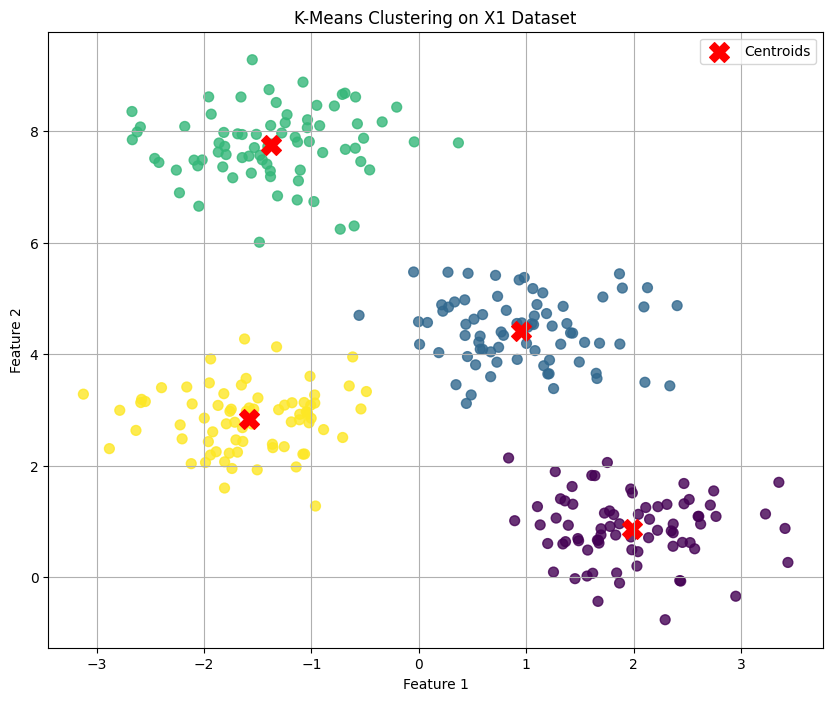

In [4]:
plt.figure(figsize=(10, 8))
plt.scatter(X1[:, 0], X1[:, 1], c=kmeans_labels, s=50, cmap='viridis', alpha=0.8)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=200, c='red', marker='X', label='Centroids')
plt.title('K-Means Clustering on X1 Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

## Apply Hierarchical Clustering

### Subtask:
Apply Hierarchical Clustering to the second sample dataset. This step should involve calculating the linkage matrix and generating a dendrogram to help determine the optimal number of clusters.


**Reasoning**:
To apply hierarchical clustering and visualize the cluster structure, I need to import the necessary functions for calculating the linkage matrix and plotting the dendrogram. I will calculate the linkage matrix for `X2` using the 'ward' method, and then generate a dendrogram to visualize the clustering process and help determine the optimal number of clusters.



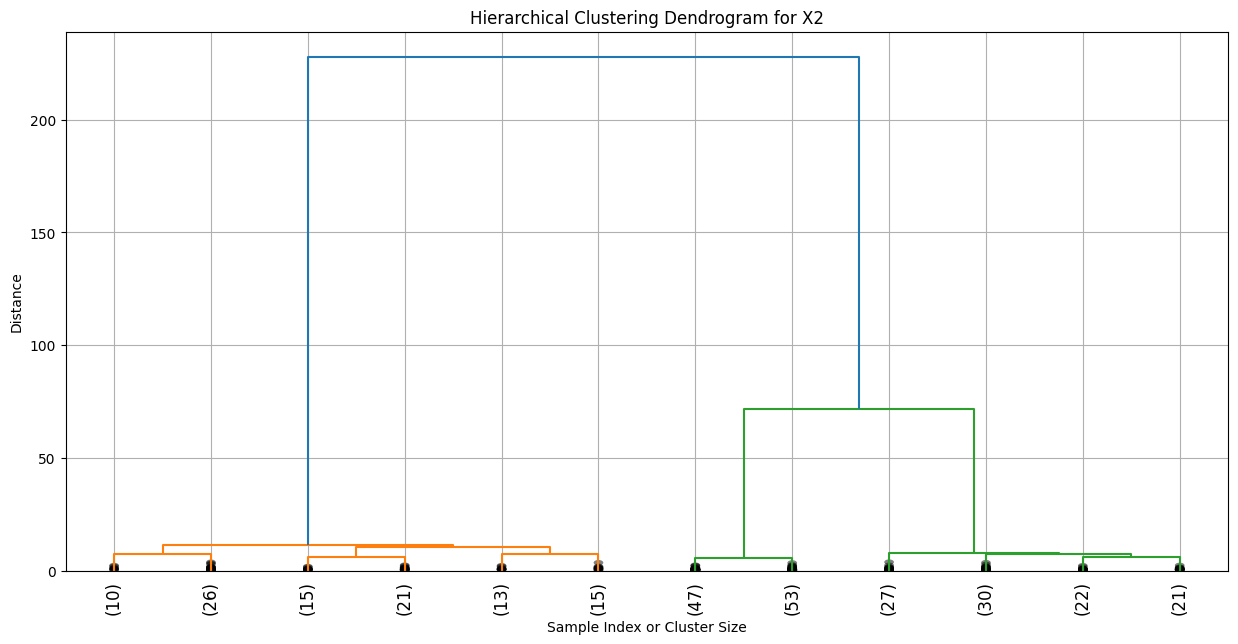

Linkage matrix calculated and dendrogram plotted.


In [5]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

# Calculate the linkage matrix
Z = linkage(X2, method='ward')

# Plot the dendrogram
plt.figure(figsize=(15, 7))
plt.title('Hierarchical Clustering Dendrogram for X2')
plt.xlabel('Sample Index or Cluster Size')
plt.ylabel('Distance')
dendrogram(
    Z,
    truncate_mode='lastp',  # show only the last p merged clusters
    p=12,  # show only the last 12 merged clusters
    show_leaf_counts=True,  # otherwise numbers in brackets are counts
    leaf_rotation=90.,
    leaf_font_size=12.,
    show_contracted=True,  # to get a distribution impression in truncated branches
)
plt.grid(True)
plt.show()

print("Linkage matrix calculated and dendrogram plotted.")

**Reasoning**:
Based on the dendrogram generated in the previous step, which shows three distinct major branches, and considering that the `X2` dataset was generated with 3 centers, the optimal number of clusters for Hierarchical Clustering is determined to be 3. The next step is to apply `AgglomerativeClustering` with this optimal number of clusters to the `X2` dataset to obtain the cluster labels.



In [6]:
from sklearn.cluster import AgglomerativeClustering

# Based on the dendrogram, choose the optimal number of clusters
hc_optimal_clusters = 3

# Apply Agglomerative Clustering
hc = AgglomerativeClustering(n_clusters=hc_optimal_clusters, linkage='ward')
hc_labels = hc.fit_predict(X2)

print(f"Hierarchical Clustering applied with {hc_optimal_clusters} clusters.")
print(f"First 10 cluster labels: {hc_labels[:10]}")

Hierarchical Clustering applied with 3 clusters.
First 10 cluster labels: [0 2 0 1 1 0 1 1 2 0]


**Reasoning**:
To visualize the results of Hierarchical Clustering on the `X2` dataset, I will create a 3D scatter plot. Since `X2` has three features, a 3D plot will effectively represent the clustered data points, colored according to the `hc_labels` obtained from `AgglomerativeClustering`.



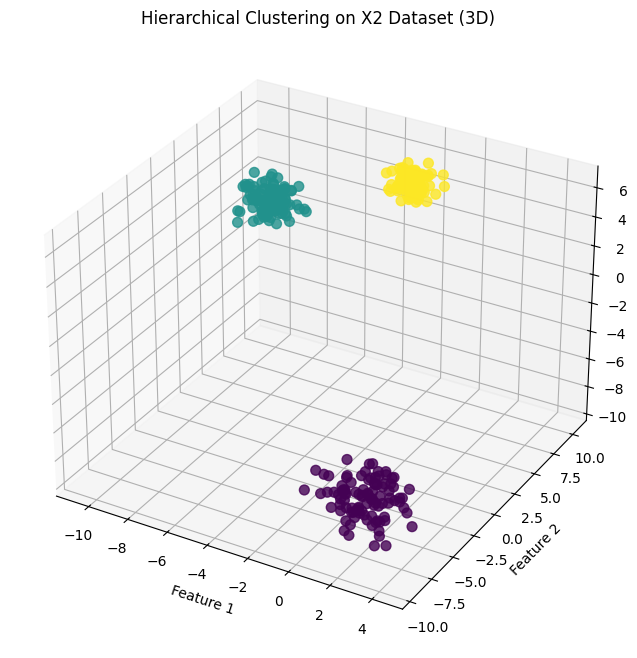

In [7]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X2[:, 0], X2[:, 1], X2[:, 2], c=hc_labels, s=50, cmap='viridis', alpha=0.8)

ax.set_title('Hierarchical Clustering on X2 Dataset (3D)')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_zlabel('Feature 3')
plt.show()

## Final Task

### Subtask:
Provide a summary comparing the results and characteristics of both K-Means and Hierarchical Clustering as applied to the sample datasets.


## Summary:

### Q&A

The task was to provide a summary comparing the results and characteristics of both K-Means and Hierarchical Clustering as applied to the sample datasets.

*   **K-Means Clustering:**
    *   **Results**: Applied to a 2-feature dataset (`X1`) of 300 samples, the elbow method identified 4 as the optimal number of clusters. The resulting visualization clearly showed 4 well-separated clusters with distinct centroids.
    *   **Characteristics**: K-Means is a partitioning clustering algorithm that aims to partition `n` observations into `k` clusters. It requires the number of clusters (`k`) to be specified in advance and is generally more computationally efficient, especially for large datasets. It tends to form spherical clusters of similar sizes and can be sensitive to the initial placement of centroids.

*   **Hierarchical Clustering:**
    *   **Results**: Applied to a 3-feature dataset (`X2`) of 300 samples, a dendrogram was generated using the 'ward' linkage method. Visual inspection of the dendrogram suggested 3 as the optimal number of clusters. The 3D visualization confirmed the formation of 3 distinct clusters.
    *   **Characteristics**: Hierarchical Clustering is an agglomerative (bottom-up) clustering algorithm that builds a hierarchy of clusters. It does not require the number of clusters to be specified beforehand, as `k` can be determined by cutting the dendrogram at an appropriate height. It provides a visual representation of cluster formation and relationships, but it can be computationally more intensive and less scalable than K-Means for very large datasets. The choice of linkage method (e.g., 'ward') significantly influences the cluster structure.

### Data Analysis Key Findings

*   **Dataset Generation**: Two distinct datasets were generated:
    *   `X1` (300 samples, 2 features, 4 true centers) for K-Means.
    *   `X2` (300 samples, 3 features, 3 true centers) for Hierarchical Clustering.
*   **K-Means Clustering on X1**:
    *   The elbow method, by plotting Inertia (Sum of Squared Errors) against the number of clusters, indicated an optimal `k` of 4.
    *   A K-Means model with 4 clusters was fitted, successfully assigning labels to the data points and identifying distinct centroids.
    *   The visualization clearly depicted 4 separated clusters in the 2D feature space.
*   **Hierarchical Clustering on X2**:
    *   A linkage matrix was calculated, and a dendrogram was generated, visually supporting an optimal number of 3 clusters based on the 'ward' linkage method.
    *   Agglomerative Clustering was applied with 3 clusters, effectively assigning labels to the 3D data points.
    *   The 3D visualization confirmed the presence of 3 distinct clusters.

### Insights or Next Steps

*   The choice between K-Means and Hierarchical Clustering depends on the dataset's characteristics and the problem's objective. K-Means is suitable when the number of clusters is known or can be estimated, and clusters are expected to be spherical, while Hierarchical Clustering is better for exploring cluster hierarchies or when the number of clusters is unknown and a visual representation of relationships is desired.
*   Further analysis could involve evaluating the quality of the clusters obtained by both methods using internal validation metrics (e.g., Silhouette Score, Davies-Bouldin index) for a more quantitative comparison, especially if the ground truth labels were not available.
